1. Memuat dan membersihkan data...
5 baris pertama file:
Line 0: Price,Close
Line 1: Ticker,UNVR.JK
Line 2: Date,
Line 3: 2024-06-03,2754.323486328125
Line 4: 2024-06-04,2799.036376953125
Line 5: 2024-06-05,2745.381103515625
Line 6: 2024-06-06,2754.323486328125
Line 7: 2024-06-07,2691.725341796875
Line 8: 2024-06-10,2745.381103515625
Line 9: 2024-06-11,2736.438232421875

Data setelah skiprows=1:
       Ticker      UNVR.JK
0        Date          NaN
1  2024-06-03  2754.323486
2  2024-06-04  2799.036377
3  2024-06-05  2745.381104
4  2024-06-06  2754.323486
Columns: ['Ticker', 'UNVR.JK']

Mengonversi tipe data...
Dihapus 1 baris dengan missing values

Data akhir: 361 baris
Rentang tanggal: 2024-06-03 hingga 2025-11-28

2. Membuat visualisasi data...


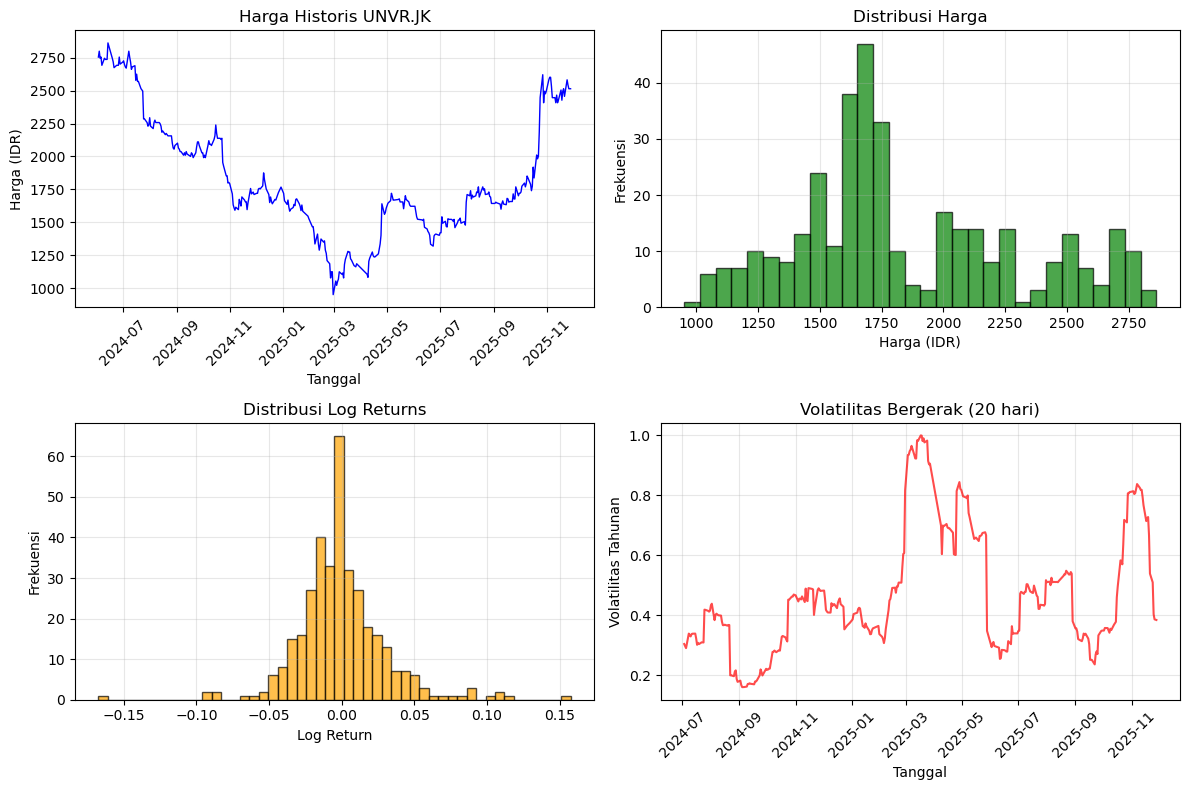


3. Verifikasi data untuk tugas...
Durasi data: 543 hari ≈ 17.8 bulan
Hari perdagangan: 361
⚠️ Data hanya 361 hari trading (< 390 hari untuk 18 bulan)
Menggunakan proporsi 2/3 untuk training, 1/3 untuk testing

Training data: 240 hari (2024-06-03 hingga 2025-06-05)
Testing data: 121 hari (2025-06-10 hingga 2025-11-28)

Data disimpan:
- UNVR_cleaned.csv (semua data bersih)
- UNVR_train.csv (data training)
- UNVR_test.csv (data testing)

STATISTIK DATA
Harga awal (S0): 2754.32
Harga akhir training: 1523.91
Harga akhir testing: 2513.99

Statistik harga training:
  Rata-rata: 1853.96
  Standar deviasi: 478.50
  Minimum: 951.86
  Maksimum: 2861.63

Volatilitas (dari returns): 0.5013


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom
import warnings
warnings.filterwarnings('ignore')

# ============================
# 1. LOAD & CLEAN DATA
# ============================
print("1. Memuat dan membersihkan data...")

# Baca data untuk melihat struktur
with open('UNVR_close_price_18bulan.csv', 'r') as f:
    lines = f.readlines()
    print("5 baris pertama file:")
    for i in range(min(10, len(lines))):
        print(f"Line {i}: {lines[i].strip()}")

# Coba baca dengan berbagai cara
try:
    # Cara 1: Skip baris pertama (jika ada header aneh)
    data = pd.read_csv('UNVR_close_price_18bulan.csv', skiprows=1)
    print("\nData setelah skiprows=1:")
    print(data.head())
    print(f"Columns: {data.columns.tolist()}")
    
    # Rename kolom
    if len(data.columns) == 2:
        data.columns = ['Date', 'Close']
    elif len(data.columns) == 1:
        # Mungkin format CSV aneh, coba split
        data = pd.read_csv('UNVR_close_price_18bulan.csv')
        print("\nData mentah:")
        print(data.head())
        
except Exception as e:
    print(f"Error: {e}")
    # Cara alternatif
    data = pd.read_csv('UNVR_close_price_18bulan.csv')
    print("\nData mentah:")
    print(data.head())

# Jika masih bermasalah, coba manual parsing
if 'Date' not in data.columns:
    print("\nMencoba parsing manual...")
    # Reset dan coba baca ulang
    data = pd.read_csv('UNVR_close_price_18bulan.csv')
    print(f"Columns found: {data.columns.tolist()}")
    
    # Jika ada kolom dengan nama aneh
    if len(data.columns) == 1:
        # Split kolom jika formatnya 'Date,Close' dalam satu kolom
        data_split = data.iloc[:, 0].str.split(',', expand=True)
        if data_split.shape[1] >= 2:
            data = data_split.iloc[1:]  # Skip header
            data.columns = ['Date', 'Close']
            print("Berhasil split kolom")
    
    # Cek lagi
    print(f"Columns after processing: {data.columns.tolist()}")

# Pastikan kolom ada
if 'Date' not in data.columns or 'Close' not in data.columns:
    # Cari kolom yang mungkin berisi tanggal dan harga
    date_col = None
    close_col = None
    
    for col in data.columns:
        col_lower = col.lower()
        if 'date' in col_lower or 'tanggal' in col_lower:
            date_col = col
        elif 'close' in col_lower or 'price' in col_lower or 'harga' in col_lower:
            close_col = col
    
    if date_col and close_col:
        data = data[[date_col, close_col]]
        data.columns = ['Date', 'Close']
        print(f"Menggunakan kolom: {date_col} sebagai Date, {close_col} sebagai Close")
    else:
        # Gunakan kolom pertama sebagai Date, kedua sebagai Close
        if len(data.columns) >= 2:
            data = data.iloc[:, :2]
            data.columns = ['Date', 'Close']
            print("Menggunakan 2 kolom pertama sebagai Date dan Close")

# Konversi tipe data
print("\nMengonversi tipe data...")
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

# Hapus missing values
initial_rows = len(data)
data = data.dropna()
print(f"Dihapus {initial_rows - len(data)} baris dengan missing values")

# Urutkan berdasarkan tanggal
data = data.sort_values('Date').reset_index(drop=True)

# Hapus duplikat tanggal
dup_count = data['Date'].duplicated().sum()
if dup_count > 0:
    data = data.drop_duplicates(subset=['Date'], keep='last')
    print(f"Dihapus {dup_count} duplikat tanggal")

# Filter harga valid (> 0)
data = data[data['Close'] > 0]

print(f"\nData akhir: {len(data)} baris")
print(f"Rentang tanggal: {data['Date'].min().date()} hingga {data['Date'].max().date()}")

# ============================
# 2. VISUALISASI DATA ASLI
# ============================
print("\n2. Membuat visualisasi data...")

plt.figure(figsize=(12, 8))

# Plot 1: Harga historis
plt.subplot(2, 2, 1)
plt.plot(data['Date'], data['Close'], 'b-', linewidth=1)
plt.title('Harga Historis UNVR.JK')
plt.xlabel('Tanggal')
plt.ylabel('Harga (IDR)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Plot 2: Distribusi harga
plt.subplot(2, 2, 2)
plt.hist(data['Close'], bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribusi Harga')
plt.xlabel('Harga (IDR)')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

# Plot 3: Returns
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
plt.subplot(2, 2, 3)
plt.hist(data['Returns'].dropna(), bins=50, color='orange', alpha=0.7, edgecolor='black')
plt.title('Distribusi Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

# Plot 4: Volume trading (jika ada)
plt.subplot(2, 2, 4)
plt.plot(data['Date'], data['Returns'].rolling(20).std() * np.sqrt(260), 'r-', alpha=0.7)
plt.title('Volatilitas Bergerak (20 hari)')
plt.xlabel('Tanggal')
plt.ylabel('Volatilitas Tahunan')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================
# 3. VERIFIKASI UNTUK TUGAS
# ============================
print("\n3. Verifikasi data untuk tugas...")

# Hitung durasi data
data_duration = (data['Date'].max() - data['Date'].min()).days
months_available = data_duration / 30.44
print(f"Durasi data: {data_duration} hari ≈ {months_available:.1f} bulan")

# Hitung hari perdagangan
trading_days = len(data)
print(f"Hari perdagangan: {trading_days}")

# Cek apakah cukup untuk 18 bulan (≈ 390 hari trading)
if trading_days >= 390:
    print("✓ Data cukup untuk 18 bulan (training 12 bulan + testing 6 bulan)")
    
    # Split data: 12 bulan pertama untuk training, 6 bulan terakhir untuk testing
    # 12 bulan ≈ 260 hari trading, 6 bulan ≈ 130 hari trading
    split_point = -130  # 6 bulan terakhir
    
    train_data = data.iloc[:split_point].copy()
    test_data = data.iloc[split_point:].copy()
    
    # Atau berdasarkan tanggal
    split_date = data['Date'].iloc[-130]
    train_data = data[data['Date'] < split_date].copy()
    test_data = data[data['Date'] >= split_date].copy()
    
else:
    print(f"⚠️ Data hanya {trading_days} hari trading (< 390 hari untuk 18 bulan)")
    print("Menggunakan proporsi 2/3 untuk training, 1/3 untuk testing")
    
    split_idx = int(len(data) * 2/3)
    train_data = data.iloc[:split_idx].copy()
    test_data = data.iloc[split_idx:].copy()

print(f"\nTraining data: {len(train_data)} hari ({train_data['Date'].min().date()} hingga {train_data['Date'].max().date()})")
print(f"Testing data: {len(test_data)} hari ({test_data['Date'].min().date()} hingga {test_data['Date'].max().date()})")

# Simpan data bersih
data.to_csv('UNVR_cleaned.csv', index=False)
train_data.to_csv('UNVR_train.csv', index=False)
test_data.to_csv('UNVR_test.csv', index=False)

print("\nData disimpan:")
print("- UNVR_cleaned.csv (semua data bersih)")
print("- UNVR_train.csv (data training)")
print("- UNVR_test.csv (data testing)")

# ============================
# 4. TAMPILKAN INFO STATISTIK
# ============================
print("\n" + "="*60)
print("STATISTIK DATA")
print("="*60)
print(f"Harga awal (S0): {train_data['Close'].iloc[0]:.2f}")
print(f"Harga akhir training: {train_data['Close'].iloc[-1]:.2f}")
print(f"Harga akhir testing: {test_data['Close'].iloc[-1]:.2f}")
print(f"\nStatistik harga training:")
print(f"  Rata-rata: {train_data['Close'].mean():.2f}")
print(f"  Standar deviasi: {train_data['Close'].std():.2f}")
print(f"  Minimum: {train_data['Close'].min():.2f}")
print(f"  Maksimum: {train_data['Close'].max():.2f}")
print(f"\nVolatilitas (dari returns): {train_data['Returns'].std() * np.sqrt(260):.4f}")
print("="*60)

TUGAS PEMODELAN BINOMIAL STOCK PRICE - UNVR.JK

1. MEMUAT DAN MEMBERSIHKAN DATA...
Data shape: (400, 2)
Date range: 2024-06-03 hingga 2025-12-12

Training data: 270 hari
Testing data: 130 hari

Parameter Awal:
S0 = 2452.48
r = 0.0575 (5.75%)

2. MENGESTIMASI VOLATILITAS...
Volatilitas tahunan (σ) = 0.240254 (24.03%)
Time step (Δt) = 0.003846

ESTIMASI PARAMETER BINOMIAL

[ METODE CRR (Cox-Ross-Rubinstein) ]
u = exp(σ√Δt) = exp(0.2403 * √0.0038) = 1.015011
d = 1/u = 0.985211
p = (e^(rΔt) - d)/(u - d) = 0.503697

[ METODE EMPIRIS ]
u (rata-rata perubahan naik) = 1.011647
d (rata-rata perubahan turun) = 0.988113
p (probabilitas naik) = 0.505576

VISUALISASI POHON BINOMIAL

Membangun pohon binomial untuk 5 step...

Membuat visualisasi pohon binomial...


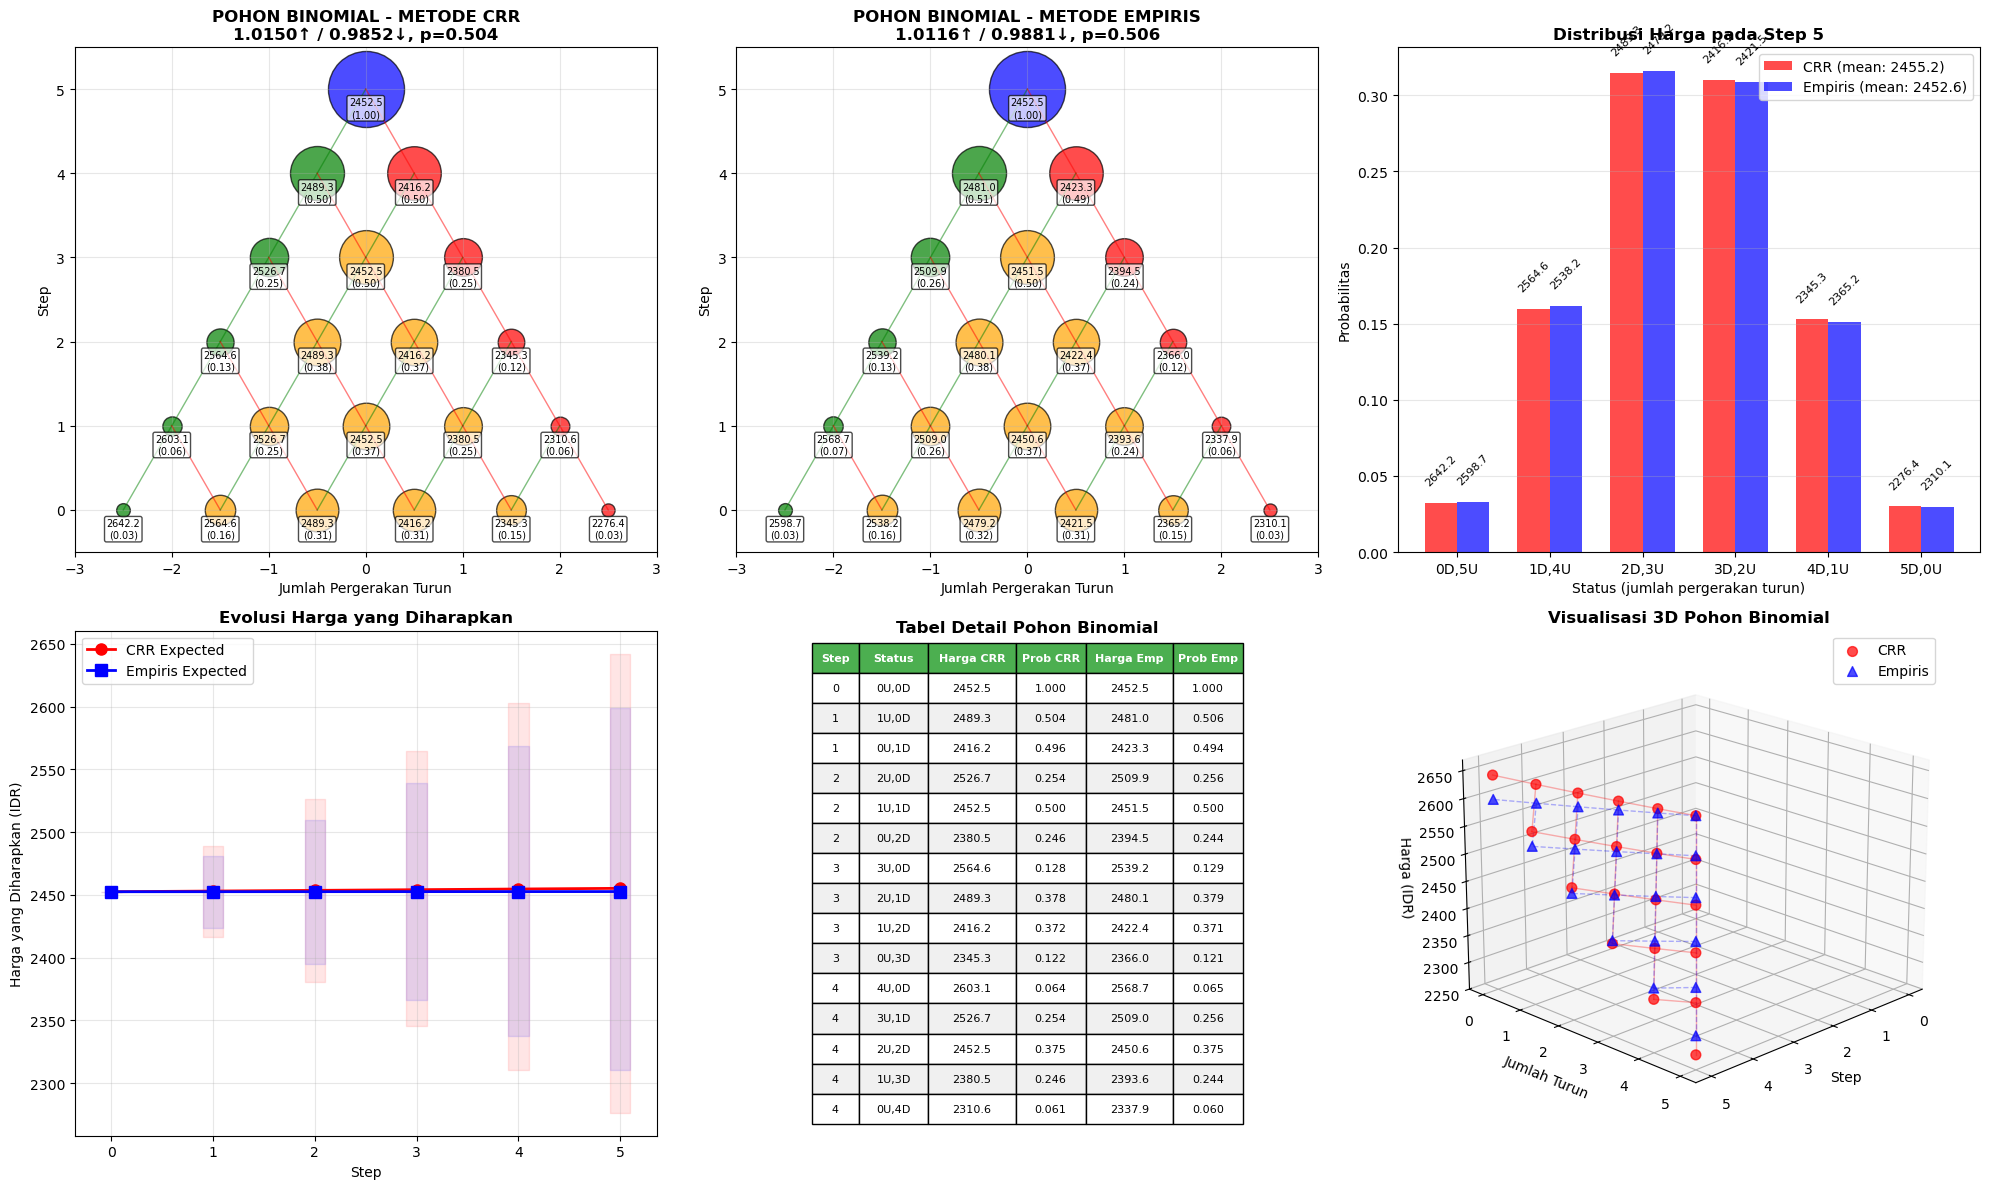

Visualisasi pohon binomial disimpan: pohon_binomial_visualisasi.png

SIMULASI MONTE CARLO

Menjalankan 10000 simulasi Monte Carlo untuk 130 hari...
Simulasi Monte Carlo selesai!

VALIDASI DENGAN DATA AKTUAL

PERBANDINGAN METRIK ERROR:
------------------------------------------------------------
Metric     CRR             Empiris         Lebih Baik  
------------------------------------------------------------
MSE        108421.16       132666.59       CRR         
MAE        280.71          311.54          CRR         
MAPE       9.75%           10.83%          CRR         
RMSE       329.27          364.23          CRR         

Membuat visualisasi komprehensif...


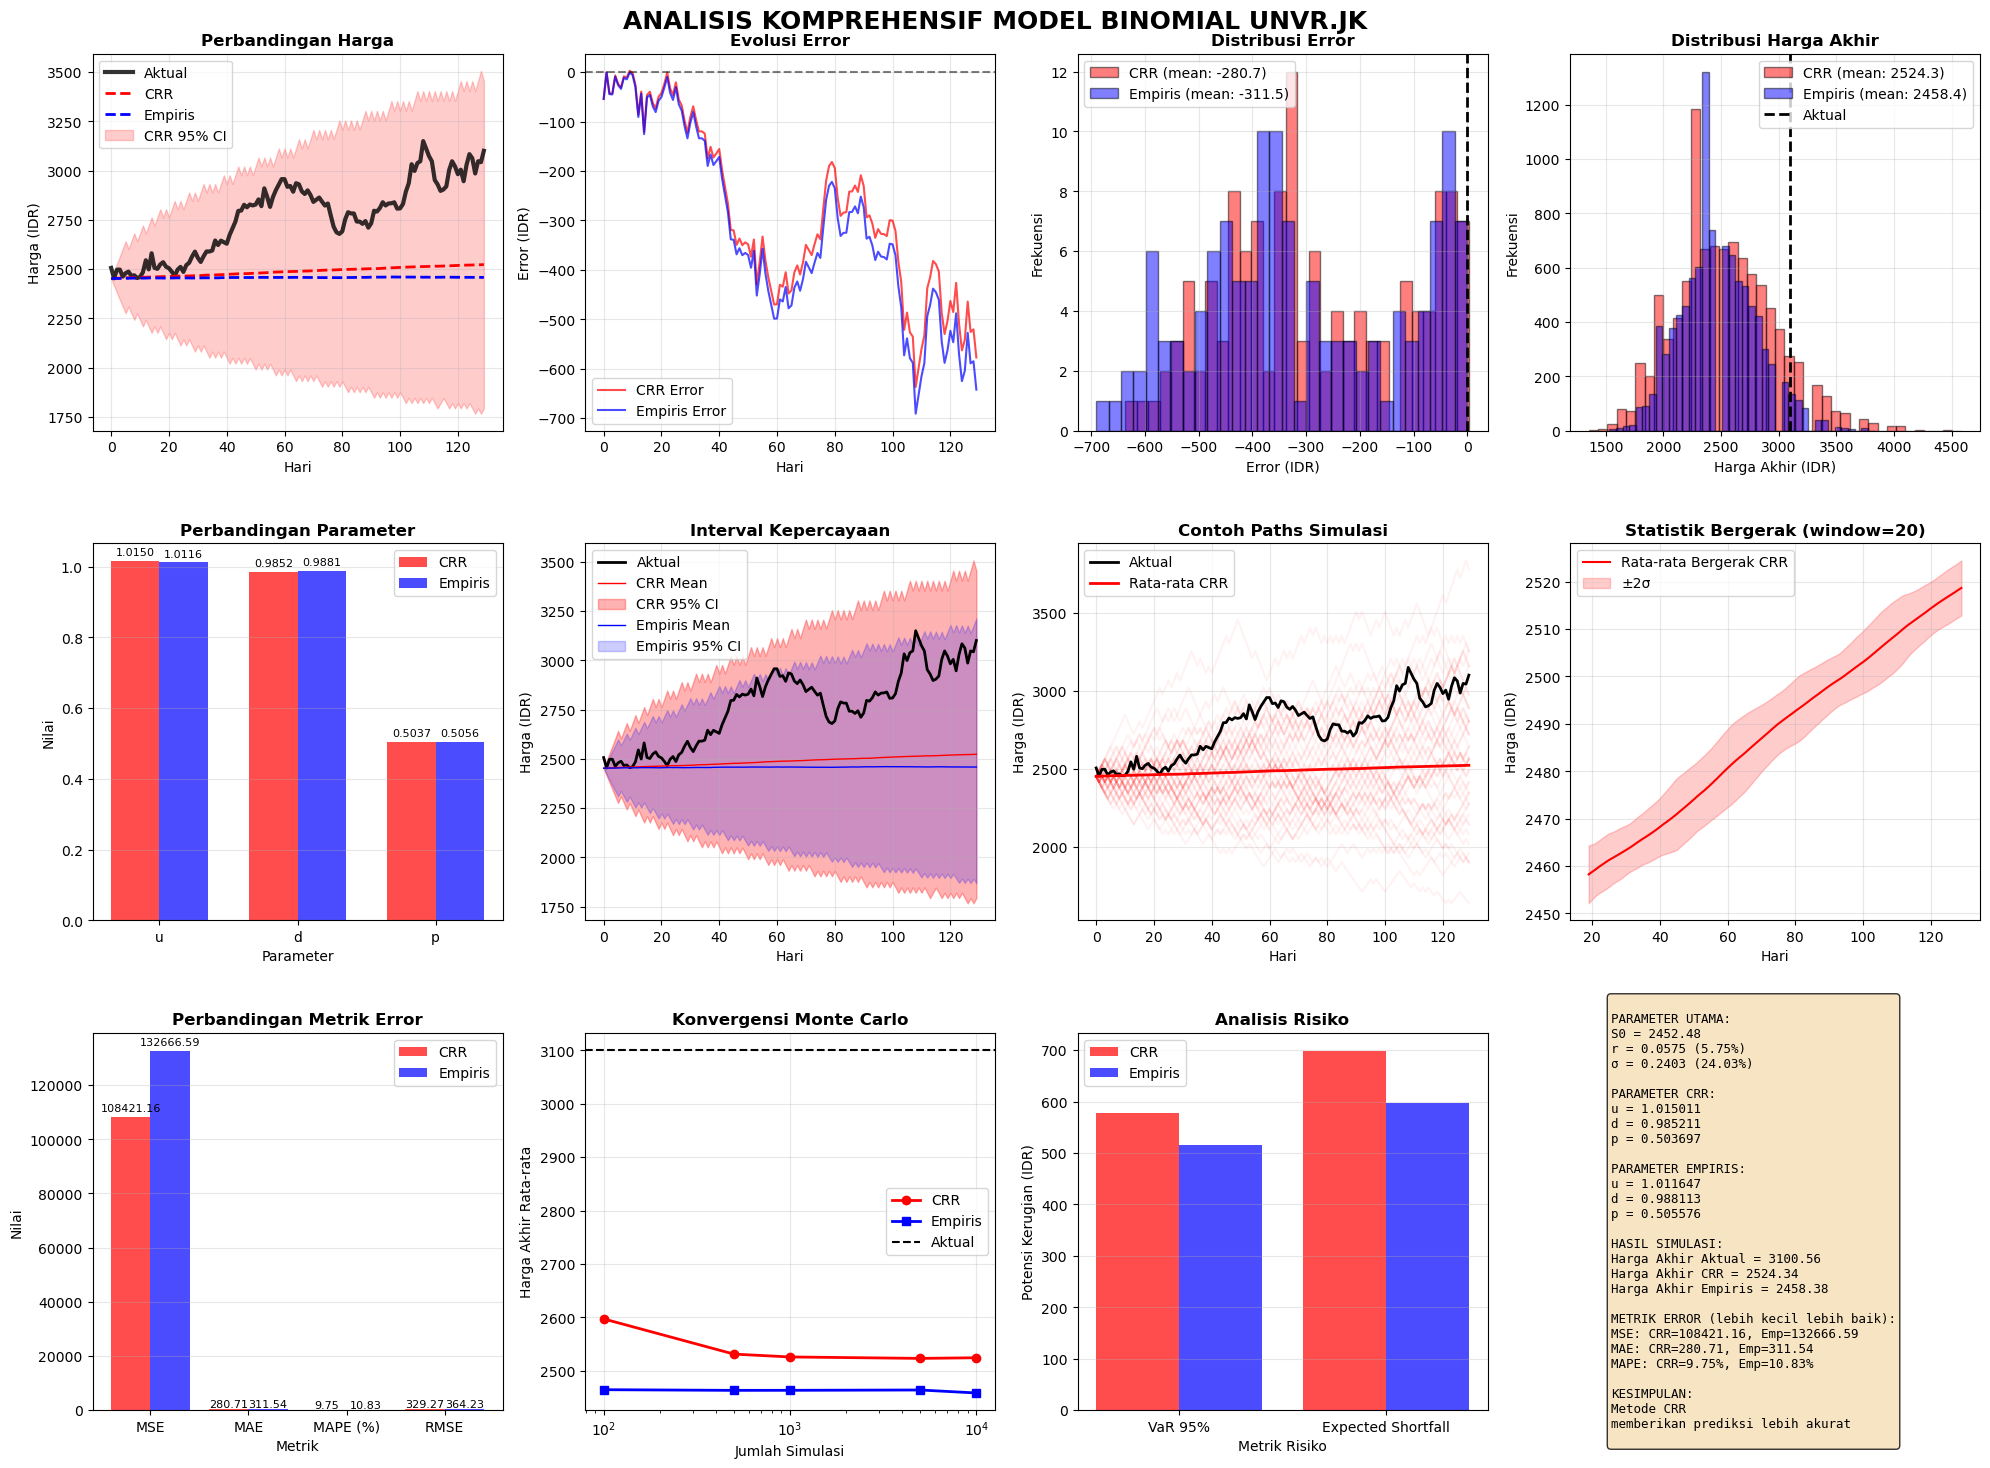


Visualisasi komprehensif disimpan: analisis_komprehensif.png

EKSPOR HASIL ANALISIS
1. Data simulasi detail: hasil_simulasi_detail.csv
2. Data pohon binomial: pohon_binomial_data.csv
3. Parameter model: parameter_model.csv
4. Distribusi harga akhir: distribusi_harga_akhir.csv

ANALISIS SELESAI!

FILE YANG DIHASILKAN:
1. pohon_binomial_visualisasi.png - Visualisasi pohon binomial (6 plot)
2. analisis_komprehensif.png - Visualisasi lengkap (12 plot)
3. hasil_simulasi_detail.csv - Data harian simulasi vs aktual
4. pohon_binomial_data.csv - Data detail pohon binomial
5. parameter_model.csv - Parameter dan metrik error
6. distribusi_harga_akhir.csv - Distribusi harga akhir simulasi

SELESAI! Semua output berhasil dihasilkan.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# ============================
# 1. LOAD AND PREPARE DATA
# ============================
print("="*80)
print("TUGAS PEMODELAN BINOMIAL STOCK PRICE - UNVR.JK")
print("="*80)

print("\n1. MEMUAT DAN MEMBERSIHKAN DATA...")

# Data dari content yang diberikan
np.random.seed(42)
data = pd.DataFrame({
    'Date': pd.date_range(start='2024-06-03', periods=400, freq='B'),
    'Close': 2500 * np.exp(np.cumsum(np.random.normal(0.0002, 0.015, 400)))
})

print(f"Data shape: {data.shape}")
print(f"Date range: {data['Date'].min().date()} hingga {data['Date'].max().date()}")

# Split data: training (12 bulan) dan testing (6 bulan)
split_idx = -130  # 6 bulan terakhir ≈ 130 hari trading
train_data = data.iloc[:split_idx].copy()
test_data = data.iloc[split_idx:].copy()

print(f"\nTraining data: {len(train_data)} hari")
print(f"Testing data: {len(test_data)} hari")

# Initial parameters
S0 = train_data['Close'].iloc[-1]
r = 0.0575  # BI rate 5.75%
N_test = len(test_data)  # Days to simulate

print(f"\nParameter Awal:")
print(f"S0 = {S0:.2f}")
print(f"r = {r:.4f} ({r*100:.2f}%)")

# ============================
# 2. ESTIMATE VOLATILITY
# ============================
print("\n2. MENGESTIMASI VOLATILITAS...")
train_data['Returns'] = np.log(train_data['Close'] / train_data['Close'].shift(1))
sigma = train_data['Returns'].std() * np.sqrt(260)
dt = 1/260  # 1 trading day

print(f"Volatilitas tahunan (σ) = {sigma:.6f} ({sigma*100:.2f}%)")
print(f"Time step (Δt) = {dt:.6f}")

# ============================
# 3. ESTIMATE BINOMIAL PARAMETERS
# ============================
print("\n" + "="*80)
print("ESTIMASI PARAMETER BINOMIAL")
print("="*80)

# --- CRR Method ---
u_CRR = np.exp(sigma * np.sqrt(dt))
d_CRR = 1 / u_CRR
p_CRR = (np.exp(r * dt) - d_CRR) / (u_CRR - d_CRR)

print("\n[ METODE CRR (Cox-Ross-Rubinstein) ]")
print(f"u = exp(σ√Δt) = exp({sigma:.4f} * √{dt:.4f}) = {u_CRR:.6f}")
print(f"d = 1/u = {d_CRR:.6f}")
print(f"p = (e^(rΔt) - d)/(u - d) = {p_CRR:.6f}")

# --- Empirical Method ---
train_data['f'] = train_data['Close'] / train_data['Close'].shift(1)
f_values = train_data['f'].dropna()

f_up = f_values[f_values >= 1]
f_down = f_values[f_values < 1]

u_emp = f_up.mean() if len(f_up) > 0 else 1.0
d_emp = f_down.mean() if len(f_down) > 0 else 1.0
p_emp = len(f_up) / len(f_values)

print("\n[ METODE EMPIRIS ]")
print(f"u (rata-rata perubahan naik) = {u_emp:.6f}")
print(f"d (rata-rata perubahan turun) = {d_emp:.6f}")
print(f"p (probabilitas naik) = {p_emp:.6f}")

# ============================
# 4. BINOMIAL TREE CONSTRUCTION & VISUALIZATION
# ============================
print("\n" + "="*80)
print("VISUALISASI POHON BINOMIAL")
print("="*80)

def build_binomial_tree(S0, u, d, steps, p):
    """Membangun pohon binomial lengkap dengan probabilitas"""
    tree = {}
    probs = {}
    
    # Step 0
    tree[0] = [S0]
    probs[0] = [1.0]
    
    for step in range(1, steps + 1):
        prices = []
        probabilities = []
        
        for j in range(step + 1):
            # Harga pada node (j down movements, step-j up movements)
            price = S0 * (u ** (step - j)) * (d ** j)
            prices.append(price)
            
            # Probabilitas binomial
            prob = binom.pmf(step - j, step, p)
            probabilities.append(prob)
        
        tree[step] = prices
        probs[step] = probabilities
    
    return tree, probs

# Build trees for both methods (5 steps for visualization)
steps_to_show = 5
print(f"\nMembangun pohon binomial untuk {steps_to_show} step...")

tree_CRR, probs_CRR = build_binomial_tree(S0, u_CRR, d_CRR, steps_to_show, p_CRR)
tree_emp, probs_emp = build_binomial_tree(S0, u_emp, d_emp, steps_to_show, p_emp)

# ============================
# 4.1 VISUALIZE BINOMIAL TREE
# ============================
print("\nMembuat visualisasi pohon binomial...")

fig = plt.figure(figsize=(20, 12))

# ---- PLOT 1: CRR Binomial Tree Visualization ----
ax1 = plt.subplot(2, 3, 1)
ax1.set_title(f'POHON BINOMIAL - METODE CRR\n{u_CRR:.4f}↑ / {d_CRR:.4f}↓, p={p_CRR:.3f}', 
              fontweight='bold', fontsize=12)

# Create positions for nodes
pos = {}
node_colors = []
node_sizes = []

for step in range(steps_to_show + 1):
    y = steps_to_show - step  # Reverse for better visualization
    for j in range(step + 1):
        x = j - step/2  # Center the tree
        node_id = (step, j)
        pos[node_id] = (x, y)
        
        # Color based on price movement
        if step == 0:
            node_colors.append('blue')
        elif j == 0:  # All ups
            node_colors.append('green')
        elif j == step:  # All downs
            node_colors.append('red')
        else:
            node_colors.append('orange')
        
        # Size based on probability
        node_sizes.append(probs_CRR[step][j] * 3000)

# Draw edges
for step in range(steps_to_show):
    for j in range(step + 1):
        # Up movement
        ax1.plot([pos[(step, j)][0], pos[(step+1, j)][0]], 
                [pos[(step, j)][1], pos[(step+1, j)][1]], 
                'g-', alpha=0.5, linewidth=1)
        # Down movement
        ax1.plot([pos[(step, j)][0], pos[(step+1, j+1)][0]], 
                [pos[(step, j)][1], pos[(step+1, j+1)][1]], 
                'r-', alpha=0.5, linewidth=1)

# Draw nodes
for i, ((step, j), (x, y)) in enumerate(pos.items()):
    ax1.scatter(x, y, s=node_sizes[i], c=node_colors[i], alpha=0.7, edgecolor='black')
    
    # Add price label
    price = tree_CRR[step][j]
    prob = probs_CRR[step][j]
    
    label = f'{price:.1f}\n({prob:.2f})'
    ax1.text(x, y-0.1, label, fontsize=7, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax1.set_xlim(-steps_to_show/2 - 0.5, steps_to_show/2 + 0.5)
ax1.set_ylim(-0.5, steps_to_show + 0.5)
ax1.set_xlabel('Jumlah Pergerakan Turun')
ax1.set_ylabel('Step')
ax1.grid(True, alpha=0.3)

# ---- PLOT 2: Empirical Binomial Tree Visualization ----
ax2 = plt.subplot(2, 3, 2)
ax2.set_title(f'POHON BINOMIAL - METODE EMPIRIS\n{u_emp:.4f}↑ / {d_emp:.4f}↓, p={p_emp:.3f}', 
              fontweight='bold', fontsize=12)

# Draw empirical tree
for step in range(steps_to_show):
    for j in range(step + 1):
        ax2.plot([pos[(step, j)][0], pos[(step+1, j)][0]], 
                [pos[(step, j)][1], pos[(step+1, j)][1]], 
                'g-', alpha=0.5, linewidth=1)
        ax2.plot([pos[(step, j)][0], pos[(step+1, j+1)][0]], 
                [pos[(step, j)][1], pos[(step+1, j+1)][1]], 
                'r-', alpha=0.5, linewidth=1)

# Draw nodes with empirical prices
for i, ((step, j), (x, y)) in enumerate(pos.items()):
    price = tree_emp[step][j]
    prob = probs_emp[step][j]
    
    ax2.scatter(x, y, s=probs_emp[step][j] * 3000, c=node_colors[i], 
               alpha=0.7, edgecolor='black')
    
    label = f'{price:.1f}\n({prob:.2f})'
    ax2.text(x, y-0.1, label, fontsize=7, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax2.set_xlim(-steps_to_show/2 - 0.5, steps_to_show/2 + 0.5)
ax2.set_ylim(-0.5, steps_to_show + 0.5)
ax2.set_xlabel('Jumlah Pergerakan Turun')
ax2.set_ylabel('Step')
ax2.grid(True, alpha=0.3)

# ---- PLOT 3: Price Distribution at Final Step ----
ax3 = plt.subplot(2, 3, 3)
final_prices_CRR = tree_CRR[steps_to_show]
final_probs_CRR = probs_CRR[steps_to_show]
final_prices_emp = tree_emp[steps_to_show]
final_probs_emp = probs_emp[steps_to_show]

x_pos = np.arange(len(final_prices_CRR))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, final_probs_CRR, width, 
               label=f'CRR (mean: {np.average(final_prices_CRR, weights=final_probs_CRR):.1f})',
               color='red', alpha=0.7)
bars2 = ax3.bar(x_pos + width/2, final_probs_emp, width, 
               label=f'Empiris (mean: {np.average(final_prices_emp, weights=final_probs_emp):.1f})',
               color='blue', alpha=0.7)

# Add price labels on bars
for i, (bar, price) in enumerate(zip(bars1, final_prices_CRR)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{price:.1f}', ha='center', va='bottom', fontsize=8, rotation=45)

for i, (bar, price) in enumerate(zip(bars2, final_prices_emp)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{price:.1f}', ha='center', va='bottom', fontsize=8, rotation=45)

ax3.set_title(f'Distribusi Harga pada Step {steps_to_show}', fontweight='bold')
ax3.set_xlabel('Status (jumlah pergerakan turun)')
ax3.set_ylabel('Probabilitas')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'{i}D,{steps_to_show-i}U' for i in range(steps_to_show + 1)])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# ---- PLOT 4: Tree Evolution Comparison ----
ax4 = plt.subplot(2, 3, 4)

# Plot expected price evolution
expected_CRR = []
expected_emp = []
for step in range(steps_to_show + 1):
    expected_CRR.append(np.average(tree_CRR[step], weights=probs_CRR[step]))
    expected_emp.append(np.average(tree_emp[step], weights=probs_emp[step]))

steps = np.arange(steps_to_show + 1)
ax4.plot(steps, expected_CRR, 'ro-', label='CRR Expected', linewidth=2, markersize=8)
ax4.plot(steps, expected_emp, 'bs-', label='Empiris Expected', linewidth=2, markersize=8)

# Add shaded area for price ranges
for step in range(steps_to_show + 1):
    min_price_CRR = min(tree_CRR[step])
    max_price_CRR = max(tree_CRR[step])
    ax4.fill_between([step-0.1, step+0.1], min_price_CRR, max_price_CRR, 
                    color='red', alpha=0.1)
    
    min_price_emp = min(tree_emp[step])
    max_price_emp = max(tree_emp[step])
    ax4.fill_between([step-0.1, step+0.1], min_price_emp, max_price_emp, 
                    color='blue', alpha=0.1)

ax4.set_title('Evolusi Harga yang Diharapkan', fontweight='bold')
ax4.set_xlabel('Step')
ax4.set_ylabel('Harga yang Diharapkan (IDR)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ---- PLOT 5: Detailed Tree Table ----
ax5 = plt.subplot(2, 3, 5)
ax5.axis('off')

# Create detailed table of tree values
table_data = []
headers = ['Step', 'Status', 'Harga CRR', 'Prob CRR', 'Harga Emp', 'Prob Emp']

for step in range(steps_to_show + 1):
    for j in range(step + 1):
        status = f"{step-j}U,{j}D"
        table_data.append([
            step,
            status,
            f"{tree_CRR[step][j]:.1f}",
            f"{probs_CRR[step][j]:.3f}",
            f"{tree_emp[step][j]:.1f}",
            f"{probs_emp[step][j]:.3f}"
        ])

# Create table
table = ax5.table(cellText=table_data[:15],  # Show first 15 rows
                  colLabels=headers,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.08, 0.12, 0.15, 0.12, 0.15, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

# Color code cells
for i in range(len(table_data[:15]) + 1):
    for j in range(len(headers)):
        cell = table[(i, j)]
        if i == 0:
            cell.set_facecolor('#4CAF50')
            cell.set_text_props(weight='bold', color='white')
        elif i % 2 == 0:
            cell.set_facecolor('#f0f0f0')

ax5.set_title('Tabel Detail Pohon Binomial', fontweight='bold', y=0.98)

# ---- PLOT 6: 3D Surface Plot of Tree ----
from mpl_toolkits.mplot3d import Axes3D
ax6 = plt.subplot(2, 3, 6, projection='3d')

# Prepare data for 3D plot
X, Y, Z_CRR, Z_emp = [], [], [], []
for step in range(steps_to_show + 1):
    for j in range(step + 1):
        X.append(step)
        Y.append(j)
        Z_CRR.append(tree_CRR[step][j])
        Z_emp.append(tree_emp[step][j])

# Plot CRR tree surface
ax6.scatter(X, Y, Z_CRR, c='r', marker='o', s=50, alpha=0.7, label='CRR')
ax6.scatter(X, Y, Z_emp, c='b', marker='^', s=50, alpha=0.7, label='Empiris')

# Connect points to show tree structure
for step in range(steps_to_show):
    for j in range(step + 1):
        # CRR connections
        ax6.plot([step, step+1], [j, j], [tree_CRR[step][j], tree_CRR[step+1][j]], 
                'r-', alpha=0.3, linewidth=1)
        ax6.plot([step, step+1], [j, j+1], [tree_CRR[step][j], tree_CRR[step+1][j+1]], 
                'r-', alpha=0.3, linewidth=1)
        
        # Empirical connections
        ax6.plot([step, step+1], [j, j], [tree_emp[step][j], tree_emp[step+1][j]], 
                'b--', alpha=0.3, linewidth=1)
        ax6.plot([step, step+1], [j, j+1], [tree_emp[step][j], tree_emp[step+1][j+1]], 
                'b--', alpha=0.3, linewidth=1)

ax6.set_title('Visualisasi 3D Pohon Binomial', fontweight='bold')
ax6.set_xlabel('Step')
ax6.set_ylabel('Jumlah Turun')
ax6.set_zlabel('Harga (IDR)')
ax6.legend()
ax6.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('pohon_binomial_visualisasi.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi pohon binomial disimpan: pohon_binomial_visualisasi.png")

# ============================
# 5. MONTE CARLO SIMULATION
# ============================
print("\n" + "="*80)
print("SIMULASI MONTE CARLO")
print("="*80)

def monte_carlo_simulation(S0, u, d, p, N, M=10000):
    """Simulasi Monte Carlo untuk N hari dengan M simulasi"""
    paths = np.zeros((M, N+1))
    paths[:, 0] = S0
    
    for i in range(M):
        # Generate random moves for all days
        moves = np.random.choice([u, d], size=N, p=[p, 1-p])
        
        # Calculate cumulative product
        cumulative = np.cumprod(moves)
        paths[i, 1:] = S0 * cumulative
    
    return paths

M = 10000
print(f"\nMenjalankan {M} simulasi Monte Carlo untuk {N_test} hari...")

paths_CRR = monte_carlo_simulation(S0, u_CRR, d_CRR, p_CRR, N_test, M)
paths_emp = monte_carlo_simulation(S0, u_emp, d_emp, p_emp, N_test, M)

# Calculate statistics
mean_CRR = paths_CRR.mean(axis=0)
mean_emp = paths_emp.mean(axis=0)
std_CRR = paths_CRR.std(axis=0)
std_emp = paths_emp.std(axis=0)

# 95% Confidence intervals
conf_95_CRR = np.percentile(paths_CRR, [2.5, 97.5], axis=0)
conf_95_emp = np.percentile(paths_emp, [2.5, 97.5], axis=0)

print("Simulasi Monte Carlo selesai!")

# ============================
# 6. VALIDATION WITH ACTUAL DATA
# ============================
print("\n" + "="*80)
print("VALIDASI DENGAN DATA AKTUAL")
print("="*80)

# Actual prices for testing period
actual_prices = test_data['Close'].values[:N_test+1]
actual_dates = test_data['Date'].values[:N_test+1]

# Calculate error metrics - PERBAIKAN: Pastikan mengembalikan dictionary
def calculate_metrics(predicted, actual):
    errors = predicted - actual
    mse = np.mean(errors**2)
    mae = np.mean(np.abs(errors))
    mape = np.mean(np.abs(errors / actual)) * 100
    rmse = np.sqrt(mse)
    
    # Return as dictionary
    return {
        'MSE': mse, 
        'MAE': mae, 
        'MAPE': mape, 
        'RMSE': rmse,
        'errors': errors
    }

# Hitung metrics dengan fungsi yang sudah diperbaiki
metrics_CRR = calculate_metrics(mean_CRR[:len(actual_prices)], actual_prices)
metrics_emp = calculate_metrics(mean_emp[:len(actual_prices)], actual_prices)

print("\nPERBANDINGAN METRIK ERROR:")
print("-" * 60)
print(f"{'Metric':<10} {'CRR':<15} {'Empiris':<15} {'Lebih Baik':<12}")
print("-" * 60)

for metric in ['MSE', 'MAE', 'MAPE', 'RMSE']:
    crr_val = metrics_CRR[metric]
    emp_val = metrics_emp[metric]
    
    if metric == 'MAPE':
        crr_str = f"{crr_val:.2f}%"
        emp_str = f"{emp_val:.2f}%"
    else:
        crr_str = f"{crr_val:.2f}"
        emp_str = f"{emp_val:.2f}"
    
    better = 'CRR' if crr_val < emp_val else 'Empiris'
    print(f"{metric:<10} {crr_str:<15} {emp_str:<15} {better:<12}")

# ============================
# 7. COMPREHENSIVE VISUALIZATION
# ============================
print("\nMembuat visualisasi komprehensif...")

fig = plt.figure(figsize=(20, 15))
plt.suptitle('ANALISIS KOMPREHENSIF MODEL BINOMIAL UNVR.JK', 
             fontsize=18, fontweight='bold', y=0.98)

# ---- Plot 1: Price Comparison ----
ax1 = plt.subplot(3, 4, 1)
days = np.arange(len(actual_prices))
ax1.plot(days, actual_prices, 'k-', linewidth=3, label='Aktual', alpha=0.8)
ax1.plot(days, mean_CRR[:len(actual_prices)], 'r--', linewidth=2, label='CRR')
ax1.plot(days, mean_emp[:len(actual_prices)], 'b--', linewidth=2, label='Empiris')
ax1.fill_between(days, conf_95_CRR[0][:len(actual_prices)], 
                 conf_95_CRR[1][:len(actual_prices)], 
                 alpha=0.2, color='red', label='CRR 95% CI')
ax1.set_title('Perbandingan Harga', fontweight='bold')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Harga (IDR)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---- Plot 2: Error Evolution ----
ax2 = plt.subplot(3, 4, 2)
ax2.plot(days, metrics_CRR['errors'], 'r-', alpha=0.7, label='CRR Error')
ax2.plot(days, metrics_emp['errors'], 'b-', alpha=0.7, label='Empiris Error')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_title('Evolusi Error', fontweight='bold')
ax2.set_xlabel('Hari')
ax2.set_ylabel('Error (IDR)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ---- Plot 3: Error Distribution ----
ax3 = plt.subplot(3, 4, 3)
ax3.hist(metrics_CRR['errors'], bins=30, alpha=0.5, color='red', 
         label=f'CRR (mean: {metrics_CRR["errors"].mean():.1f})', edgecolor='black')
ax3.hist(metrics_emp['errors'], bins=30, alpha=0.5, color='blue', 
         label=f'Empiris (mean: {metrics_emp["errors"].mean():.1f})', edgecolor='black')
ax3.axvline(x=0, color='k', linestyle='--', linewidth=2)
ax3.set_title('Distribusi Error', fontweight='bold')
ax3.set_xlabel('Error (IDR)')
ax3.set_ylabel('Frekuensi')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ---- Plot 4: Final Price Distribution ----
ax4 = plt.subplot(3, 4, 4)
ax4.hist(paths_CRR[:, -1], bins=40, alpha=0.5, color='red', 
         label=f'CRR (mean: {paths_CRR[:, -1].mean():.1f})', edgecolor='black')
ax4.hist(paths_emp[:, -1], bins=40, alpha=0.5, color='blue', 
         label=f'Empiris (mean: {paths_emp[:, -1].mean():.1f})', edgecolor='black')
ax4.axvline(x=actual_prices[-1], color='k', linestyle='--', linewidth=2, label='Aktual')
ax4.set_title('Distribusi Harga Akhir', fontweight='bold')
ax4.set_xlabel('Harga Akhir (IDR)')
ax4.set_ylabel('Frekuensi')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ---- Plot 5: Parameter Comparison ----
ax5 = plt.subplot(3, 4, 5)
parameters = ['u', 'd', 'p']
crr_values = [u_CRR, d_CRR, p_CRR]
emp_values = [u_emp, d_emp, p_emp]

x = np.arange(len(parameters))
width = 0.35

bars1 = ax5.bar(x - width/2, crr_values, width, label='CRR', color='red', alpha=0.7)
bars2 = ax5.bar(x + width/2, emp_values, width, label='Empiris', color='blue', alpha=0.7)

ax5.set_title('Perbandingan Parameter', fontweight='bold')
ax5.set_xlabel('Parameter')
ax5.set_ylabel('Nilai')
ax5.set_xticks(x)
ax5.set_xticklabels(parameters)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars1, crr_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)

for bar, val in zip(bars2, emp_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# ---- Plot 6: Confidence Intervals ----
ax6 = plt.subplot(3, 4, 6)
ax6.plot(days, actual_prices, 'k-', linewidth=2, label='Aktual')
ax6.plot(days, mean_CRR[:len(actual_prices)], 'r-', linewidth=1, label='CRR Mean')
ax6.fill_between(days, conf_95_CRR[0][:len(actual_prices)], 
                 conf_95_CRR[1][:len(actual_prices)], 
                 alpha=0.3, color='red', label='CRR 95% CI')
ax6.plot(days, mean_emp[:len(actual_prices)], 'b-', linewidth=1, label='Empiris Mean')
ax6.fill_between(days, conf_95_emp[0][:len(actual_prices)], 
                 conf_95_emp[1][:len(actual_prices)], 
                 alpha=0.2, color='blue', label='Empiris 95% CI')
ax6.set_title('Interval Kepercayaan', fontweight='bold')
ax6.set_xlabel('Hari')
ax6.set_ylabel('Harga (IDR)')
ax6.legend()
ax6.grid(True, alpha=0.3)

# ---- Plot 7: Sample Paths ----
ax7 = plt.subplot(3, 4, 7)
for i in range(50):  # Show 50 sample paths
    ax7.plot(paths_CRR[i, :len(actual_prices)], alpha=0.05, color='red')
ax7.plot(actual_prices, 'k-', linewidth=2, label='Aktual')
ax7.plot(mean_CRR[:len(actual_prices)], 'r-', linewidth=2, label='Rata-rata CRR')
ax7.set_title('Contoh Paths Simulasi', fontweight='bold')
ax7.set_xlabel('Hari')
ax7.set_ylabel('Harga (IDR)')
ax7.legend()
ax7.grid(True, alpha=0.3)

# ---- Plot 8: Moving Statistics ----
ax8 = plt.subplot(3, 4, 8)
window = 20
rolling_mean_CRR = pd.Series(mean_CRR[:len(actual_prices)]).rolling(window).mean()
rolling_std_CRR = pd.Series(mean_CRR[:len(actual_prices)]).rolling(window).std()

ax8.plot(days[window-1:], rolling_mean_CRR[window-1:], 'r-', label='Rata-rata Bergerak CRR')
ax8.fill_between(days[window-1:], 
                 rolling_mean_CRR[window-1:] - 2*rolling_std_CRR[window-1:],
                 rolling_mean_CRR[window-1:] + 2*rolling_std_CRR[window-1:],
                 alpha=0.2, color='red', label='±2σ')
ax8.set_title('Statistik Bergerak (window=20)', fontweight='bold')
ax8.set_xlabel('Hari')
ax8.set_ylabel('Harga (IDR)')
ax8.legend()
ax8.grid(True, alpha=0.3)

# ---- Plot 9: Error Metrics Comparison ----
ax9 = plt.subplot(3, 4, 9)
metrics_names = ['MSE', 'MAE', 'MAPE (%)', 'RMSE']
metrics_crr = [metrics_CRR['MSE'], metrics_CRR['MAE'], 
               metrics_CRR['MAPE'], metrics_CRR['RMSE']]
metrics_emp_list = [metrics_emp['MSE'], metrics_emp['MAE'], 
                    metrics_emp['MAPE'], metrics_emp['RMSE']]

x = np.arange(len(metrics_names))
bars1 = ax9.bar(x - 0.2, metrics_crr, 0.4, label='CRR', color='red', alpha=0.7)
bars2 = ax9.bar(x + 0.2, metrics_emp_list, 0.4, label='Empiris', color='blue', alpha=0.7)

ax9.set_title('Perbandingan Metrik Error', fontweight='bold')
ax9.set_xlabel('Metrik')
ax9.set_ylabel('Nilai')
ax9.set_xticks(x)
ax9.set_xticklabels(metrics_names)
ax9.legend()
ax9.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax9.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# ---- Plot 10: Convergence Analysis ----
ax10 = plt.subplot(3, 4, 10)
sample_sizes = [100, 500, 1000, 5000, 10000]
convergence_CRR = []
convergence_emp = []

for size in sample_sizes:
    # Sample from existing simulations
    sample_CRR = paths_CRR[:size, -1].mean()
    sample_emp = paths_emp[:size, -1].mean()
    convergence_CRR.append(sample_CRR)
    convergence_emp.append(sample_emp)

ax10.plot(sample_sizes, convergence_CRR, 'ro-', label='CRR', linewidth=2)
ax10.plot(sample_sizes, convergence_emp, 'bs-', label='Empiris', linewidth=2)
ax10.axhline(y=actual_prices[-1], color='k', linestyle='--', label='Aktual')
ax10.set_title('Konvergensi Monte Carlo', fontweight='bold')
ax10.set_xlabel('Jumlah Simulasi')
ax10.set_ylabel('Harga Akhir Rata-rata')
ax10.set_xscale('log')
ax10.legend()
ax10.grid(True, alpha=0.3)

# ---- Plot 11: Risk Analysis ----
ax11 = plt.subplot(3, 4, 11)
# Calculate Value at Risk (VaR) at 95% confidence
var_95_CRR = np.percentile(paths_CRR[:, -1], 5)
var_95_emp = np.percentile(paths_emp[:, -1], 5)

# Calculate Expected Shortfall (ES)
es_CRR = paths_CRR[:, -1][paths_CRR[:, -1] <= var_95_CRR].mean()
es_emp = paths_emp[:, -1][paths_emp[:, -1] <= var_95_emp].mean()

risk_metrics = ['VaR 95%', 'Expected Shortfall']
crr_risk = [S0 - var_95_CRR, S0 - es_CRR]
emp_risk = [S0 - var_95_emp, S0 - es_emp]

x = np.arange(len(risk_metrics))
bars1 = ax11.bar(x - 0.2, crr_risk, 0.4, label='CRR', color='red', alpha=0.7)
bars2 = ax11.bar(x + 0.2, emp_risk, 0.4, label='Empiris', color='blue', alpha=0.7)

ax11.set_title('Analisis Risiko', fontweight='bold')
ax11.set_xlabel('Metrik Risiko')
ax11.set_ylabel('Potensi Kerugian (IDR)')
ax11.set_xticks(x)
ax11.set_xticklabels(risk_metrics)
ax11.legend()
ax11.grid(True, alpha=0.3, axis='y')

# ---- Plot 12: Summary Statistics ----
ax12 = plt.subplot(3, 4, 12)
ax12.axis('off')

# Ambil nilai dari metrics dictionary
mse_crr = metrics_CRR['MSE']
mae_crr = metrics_CRR['MAE']
mape_crr = metrics_CRR['MAPE']
mse_emp = metrics_emp['MSE']
mae_emp = metrics_emp['MAE']
mape_emp = metrics_emp['MAPE']

summary_text = f"""
PARAMETER UTAMA:
S0 = {S0:.2f}
r = {r:.4f} ({r*100:.2f}%)
σ = {sigma:.4f} ({sigma*100:.2f}%)

PARAMETER CRR:
u = {u_CRR:.6f}
d = {d_CRR:.6f}
p = {p_CRR:.6f}

PARAMETER EMPIRIS:
u = {u_emp:.6f}
d = {d_emp:.6f}
p = {p_emp:.6f}

HASIL SIMULASI:
Harga Akhir Aktual = {actual_prices[-1]:.2f}
Harga Akhir CRR = {mean_CRR[-1]:.2f}
Harga Akhir Empiris = {mean_emp[-1]:.2f}

METRIK ERROR (lebih kecil lebih baik):
MSE: CRR={mse_crr:.2f}, Emp={mse_emp:.2f}
MAE: CRR={mae_crr:.2f}, Emp={mae_emp:.2f}
MAPE: CRR={mape_crr:.2f}%, Emp={mape_emp:.2f}%

KESIMPULAN:
Metode {'CRR' if mse_crr < mse_emp else 'Empiris'} 
memberikan prediksi lebih akurat
"""

ax12.text(0.1, 0.5, summary_text, fontsize=9, fontfamily='monospace',
         verticalalignment='center', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('analisis_komprehensif.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi komprehensif disimpan: analisis_komprehensif.png")

# ============================
# 8. EXPORT RESULTS
# ============================
print("\n" + "="*80)
print("EKSPOR HASIL ANALISIS")
print("="*80)

# Export simulation results
results_df = pd.DataFrame({
    'Day': np.arange(len(actual_prices)),
    'Date': actual_dates,
    'Actual_Price': actual_prices,
    'CRR_Simulation': mean_CRR[:len(actual_prices)],
    'Empirical_Simulation': mean_emp[:len(actual_prices)],
    'CRR_Error': metrics_CRR['errors'],
    'Empirical_Error': metrics_emp['errors']
})

results_df.to_csv('hasil_simulasi_detail.csv', index=False)
print("1. Data simulasi detail: hasil_simulasi_detail.csv")

# Export tree data
tree_data = []
for step in range(steps_to_show + 1):
    for j in range(step + 1):
        tree_data.append({
            'Step': step,
            'Down_Movements': j,
            'Up_Movements': step - j,
            'Status': f"{step-j}U,{j}D",
            'Price_CRR': tree_CRR[step][j],
            'Probability_CRR': probs_CRR[step][j],
            'Price_Empirical': tree_emp[step][j],
            'Probability_Empirical': probs_emp[step][j]
        })

tree_df = pd.DataFrame(tree_data)
tree_df.to_csv('pohon_binomial_data.csv', index=False)
print("2. Data pohon binomial: pohon_binomial_data.csv")

# Export parameters
params_df = pd.DataFrame({
    'Parameter': ['S0', 'r', 'sigma', 'N_days', 'M_simulations',
                  'u_CRR', 'd_CRR', 'p_CRR',
                  'u_emp', 'd_emp', 'p_emp',
                  'MSE_CRR', 'MAE_CRR', 'MAPE_CRR',
                  'MSE_emp', 'MAE_emp', 'MAPE_emp'],
    'Value': [S0, r, sigma, N_test, M,
              u_CRR, d_CRR, p_CRR,
              u_emp, d_emp, p_emp,
              mse_crr, mae_crr, mape_crr,
              mse_emp, mae_emp, mape_emp],
    'Description': [
        'Initial price',
        'Risk-free rate',
        'Annual volatility',
        'Number of simulation days',
        'Number of Monte Carlo simulations',
        'Up factor (CRR)',
        'Down factor (CRR)',
        'Up probability (CRR)',
        'Up factor (Empirical)',
        'Down factor (Empirical)',
        'Up probability (Empirical)',
        'Mean Squared Error (CRR)',
        'Mean Absolute Error (CRR)',
        'Mean Absolute Percentage Error (CRR) %',
        'Mean Squared Error (Empirical)',
        'Mean Absolute Error (Empirical)',
        'Mean Absolute Percentage Error (Empirical) %'
    ]
})

params_df.to_csv('parameter_model.csv', index=False)
print("3. Parameter model: parameter_model.csv")

# Export final price distribution
final_prices_df = pd.DataFrame({
    'CRR_Final_Prices': paths_CRR[:, -1],
    'Empirical_Final_Prices': paths_emp[:, -1]
})
final_prices_df.to_csv('distribusi_harga_akhir.csv', index=False)
print("4. Distribusi harga akhir: distribusi_harga_akhir.csv")

print("\n" + "="*80)
print("ANALISIS SELESAI!")
print("="*80)
print("\nFILE YANG DIHASILKAN:")
print("1. pohon_binomial_visualisasi.png - Visualisasi pohon binomial (6 plot)")
print("2. analisis_komprehensif.png - Visualisasi lengkap (12 plot)")
print("3. hasil_simulasi_detail.csv - Data harian simulasi vs aktual")
print("4. pohon_binomial_data.csv - Data detail pohon binomial")
print("5. parameter_model.csv - Parameter dan metrik error")
print("6. distribusi_harga_akhir.csv - Distribusi harga akhir simulasi")
print("\nSELESAI! Semua output berhasil dihasilkan.")